In [1]:
import pandas as pd
df=pd.read_csv('diabetes.csv')

In [2]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
X=df.drop('Outcome',axis=1)
y=df['Outcome']

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.fit_transform(X_test)

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.regularizers import l2

model_no_reg=Sequential([
    Dense(64,input_shape=(X_train.shape[1],),activation='relu'),
    Dense(32,activation='relu'),
    Dense(1,activation='sigmoid')
])

model_no_reg.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [8]:
history_no_reg=model_no_reg.fit(X_train,y_train,epochs=10,batch_size=32,validation_split=0.2,)

Epoch 1/10
16/16 [==============================] - 3s 36ms/step - loss: 0.6768 - accuracy: 0.5845 - val_loss: 0.6246 - val_accuracy: 0.7561
Epoch 2/10
16/16 [==============================] - 0s 7ms/step - loss: 0.5892 - accuracy: 0.7556 - val_loss: 0.5766 - val_accuracy: 0.7480
Epoch 3/10
16/16 [==============================] - 0s 6ms/step - loss: 0.5377 - accuracy: 0.7597 - val_loss: 0.5374 - val_accuracy: 0.7480
Epoch 4/10
16/16 [==============================] - 0s 6ms/step - loss: 0.4971 - accuracy: 0.7699 - val_loss: 0.5104 - val_accuracy: 0.7398
Epoch 5/10
16/16 [==============================] - 0s 7ms/step - loss: 0.4719 - accuracy: 0.7699 - val_loss: 0.4872 - val_accuracy: 0.7642
Epoch 6/10
16/16 [==============================] - 0s 13ms/step - loss: 0.4559 - accuracy: 0.7821 - val_loss: 0.4754 - val_accuracy: 0.7805
Epoch 7/10
16/16 [==============================] - 0s 6ms/step - loss: 0.4432 - accuracy: 0.7780 - val_loss: 0.4678 - val_accuracy: 0.7724
Epoch 8/10
16/16 [

Text(0.5, 1.0, 'Acc without regulariser')

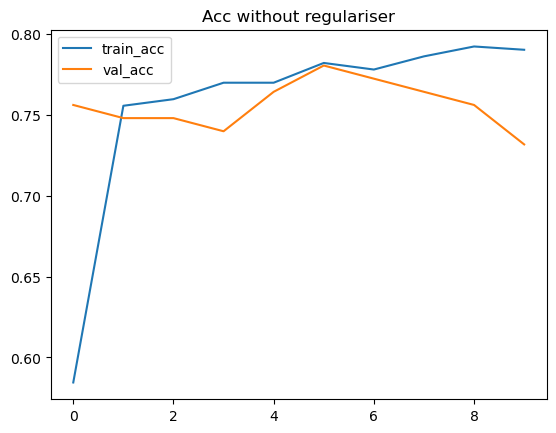

In [9]:
import matplotlib.pyplot as plt
plt.plot(history_no_reg.history['accuracy'],label='train_acc')
plt.plot(history_no_reg.history['val_accuracy'],label='val_acc')
plt.legend()
plt.title("Acc without regulariser")

In [10]:
model_with_reg=Sequential([
    Dense(256,input_shape=(X_train.shape[1],),activation='relu'),
    Dropout(0.3),
    Dense(64,activation='relu'),
    Dense(256,activation='relu',kernel_regularizer=l2(0.02)),
    Dense(1,activation='sigmoid')
])
model_with_reg.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

history_with_reg=model_with_reg.fit(X_train,y_train,epochs=10,batch_size=32,validation_split=0.2)

Epoch 1/10
16/16 [==============================] - 2s 29ms/step - loss: 2.4042 - accuracy: 0.6701 - val_loss: 2.0588 - val_accuracy: 0.6260
Epoch 2/10
16/16 [==============================] - 0s 8ms/step - loss: 1.7782 - accuracy: 0.7169 - val_loss: 1.5189 - val_accuracy: 0.7724
Epoch 3/10
16/16 [==============================] - 0s 8ms/step - loss: 1.3273 - accuracy: 0.7699 - val_loss: 1.1627 - val_accuracy: 0.7642
Epoch 4/10
16/16 [==============================] - 0s 8ms/step - loss: 1.0510 - accuracy: 0.7821 - val_loss: 0.9468 - val_accuracy: 0.7398
Epoch 5/10
16/16 [==============================] - 0s 8ms/step - loss: 0.8480 - accuracy: 0.7739 - val_loss: 0.7877 - val_accuracy: 0.7561
Epoch 6/10
16/16 [==============================] - 0s 8ms/step - loss: 0.7104 - accuracy: 0.7821 - val_loss: 0.6927 - val_accuracy: 0.7398
Epoch 7/10
16/16 [==============================] - 0s 8ms/step - loss: 0.6239 - accuracy: 0.7841 - val_loss: 0.6175 - val_accuracy: 0.7724
Epoch 8/10
16/16 [=

5/5 [==============================] - 0s 5ms/step - loss: 0.5989 - accuracy: 0.7727


Text(0.5, 1.0, 'Acc with Regulariser')

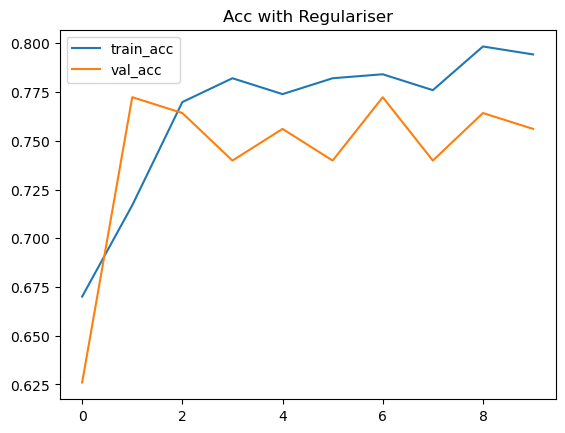

In [11]:
import matplotlib.pyplot as plt

test_with_acc=model_with_reg.evaluate(X_test,y_test)
plt.plot(history_with_reg.history['accuracy'],label='train_acc')
plt.plot(history_with_reg.history['val_accuracy'],label='val_acc')
plt.legend()
plt.title("Acc with Regulariser")


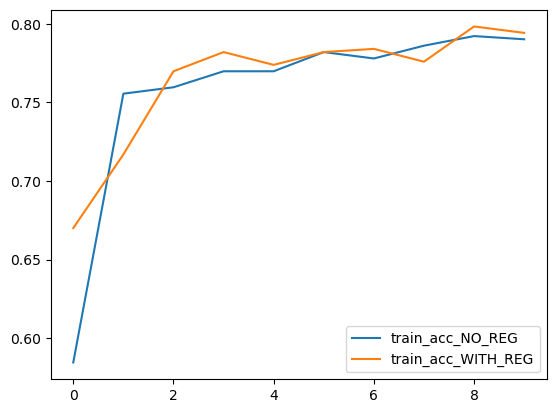

In [12]:
import matplotlib.pyplot as plt
plt.plot(history_no_reg.history['accuracy'],label='train_acc_NO_REG')
plt.plot(history_with_reg.history['accuracy'],label='train_acc_WITH_REG')
plt.legend()


In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Step 1: Get predicted probabilities
y_pred_prob = model_no_reg.predict(X_test)

# Step 2: Convert probabilities to class labels (0 or 1)
y_pred = (y_pred_prob > 0.5).astype("int32")

# Step 3: Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Optional: Classification report
cr = classification_report(y_test, y_pred)

print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", cr)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Confusion Matrix:
 [[85 14]
 [22 33]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.86      0.83        99
           1       0.70      0.60      0.65        55

    accuracy                           0.77       154
   macro avg       0.75      0.73      0.74       154
weighted avg       0.76      0.77      0.76       154



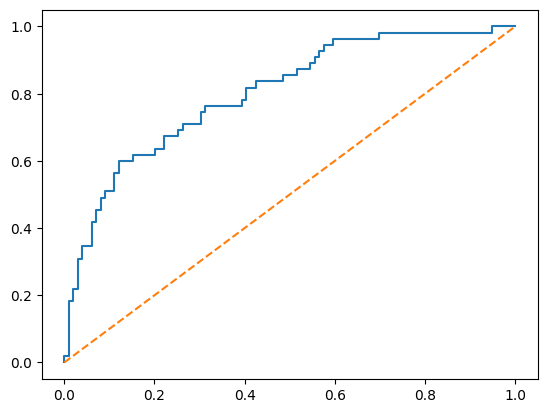

In [18]:
from sklearn.metrics import roc_curve,auc
fpr,tpr,_=roc_curve(y_test,y_pred_prob)
auc_score=auc(fpr,tpr)
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],linestyle='--')